In [1]:
!pip install kagglehub tf-explain seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.1 MB/s eta 0:00:00


In [2]:

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping
)

import kagglehub

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

from tf_explain.core.grad_cam import GradCAM

In [3]:
path = kagglehub.dataset_download(
    "sovitrath/diabetic-retinopathy-224x224-2019-data"
)

print("Dataset path:", path)

DATASET_PATH = os.path.join(path, "colored_images")

print(os.listdir(DATASET_PATH))

100%|██████████| 238M/238M [00:01<00:00, 208MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/sovitrath/diabetic-retinopathy-224x224-2019-data/versions/4
['No_DR', 'Mild', 'Moderate', 'Proliferate_DR', 'Severe']


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)


Found 2931 images belonging to 5 classes.


In [6]:
val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 731 images belonging to 5 classes.


In [7]:
class_names = list(train_generator.class_indices.keys())

print("Classes:", class_names)

print("Class Mapping:")
print(train_generator.class_indices)


Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
Class Mapping:
{'Mild': 0, 'Moderate': 1, 'No_DR': 2, 'Proliferate_DR': 3, 'Severe': 4}


In [8]:
base_model = InceptionResNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:

for layer in base_model.layers:
    layer.trainable = False


In [10]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.5)(x)

outputs = Dense(
    5,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)


In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
checkpoint = ModelCheckpoint(
    "best_inceptionresnetv2_checkpoint.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [13]:
history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.4999 - loss: 1.5841
Epoch 1: val_accuracy improved from None to 0.66895, saving model to best_inceptionresnetv2_checkpoint.h5



Epoch 1: finished saving model to best_inceptionresnetv2_checkpoint.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.5507 - loss: 1.4133 - val_accuracy: 0.6689 - val_loss: 1.0166
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.6143 - loss: 1.1554
Epoch 2: val_accuracy improved from 0.66895 to 0.68947, saving model to best_inceptionresnetv2_checkpoint.h5



Epoch 2: finished saving model to best_inceptionresnetv2_checkpoint.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 77s 614ms/step - accuracy: 0.6295 - loss: 1.0879 - val_accuracy: 0.6895 - val_loss: 0.8665
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.6247 - loss: 1.0781
Epoch 3: val_accuracy improved from 0.68947 to 0.69357, saving model to best_inceptionresnetv2_checkpoint.h5



Epoch 3: finished saving model to best_inceptionresnetv2_checkpoint.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 534ms/step - accuracy: 0.6387 - loss: 1.0558 - val_accuracy: 0.6936 - val_loss: 0.8455
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.6579 - loss: 0.9683
Epoch 4: val_accuracy improved from 0.69357 to 0.71272, saving model to best_inceptionresnetv2_checkpoint.h5



Epoch 4: finished saving model to best_inceptionresnetv2_checkpoint.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 506ms/step - accuracy: 0.6598 - loss: 0.9563 - val_accuracy: 0.7127 - val_loss: 0.7578
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.6644 - loss: 0.9348
Epoch 5: val_accuracy did not improve from 0.71272
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 491ms/step - accuracy: 0.6755 - loss: 0.9023 - val_accuracy: 0.7004 - val_loss: 0.7926


In [14]:
for layer in base_model.layers:
    layer.trainable = True

In [15]:

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [16]:

history_stage2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5018 - loss: 1.2733
Epoch 1: val_accuracy did not improve from 0.71272
92/92 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.5831 - loss: 1.1091 - val_accuracy: 0.6799 - val_loss: 0.9243
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.7007 - loss: 0.8413
Epoch 2: val_accuracy improved from 0.71272 to 0.73051, saving model to best_inceptionresnetv2_checkpoint.h5



Epoch 2: finished saving model to best_inceptionresnetv2_checkpoint.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 67s 724ms/step - accuracy: 0.7148 - loss: 0.8044 - val_accuracy: 0.7305 - val_loss: 0.7103
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.7290 - loss: 0.7294
Epoch 3: val_accuracy improved from 0.73051 to 0.76471, saving model to best_inceptionresnetv2_checkpoint.h5



Epoch 3: finished saving model to best_inceptionresnetv2_checkpoint.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 76s 821ms/step - accuracy: 0.7390 - loss: 0.7060 - val_accuracy: 0.7647 - val_loss: 0.6348
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.7616 - loss: 0.6430
Epoch 4: val_accuracy improved from 0.76471 to 0.78112, saving model to best_inceptionresnetv2_checkpoint.h5



Epoch 4: finished saving model to best_inceptionresnetv2_checkpoint.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 72s 781ms/step - accuracy: 0.7526 - loss: 0.6679 - val_accuracy: 0.7811 - val_loss: 0.5941
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.7672 - loss: 0.6147
Epoch 5: val_accuracy improved from 0.78112 to 0.78523, saving model to best_inceptionresnetv2_checkpoint.h5



Epoch 5: finished saving model to best_inceptionresnetv2_checkpoint.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 81s 881ms/step - accuracy: 0.7653 - loss: 0.6264 - val_accuracy: 0.7852 - val_loss: 0.5746
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.7590 - loss: 0.6094
Epoch 6: val_accuracy improved from 0.78523 to 0.78796, saving model to best_inceptionresnetv2_checkpoint.h5



Epoch 6: finished saving model to best_inceptionresnetv2_checkpoint.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 811ms/step - accuracy: 0.7721 - loss: 0.5918 - val_accuracy: 0.7880 - val_loss: 0.5647
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.7958 - loss: 0.5386
Epoch 7: val_accuracy did not improve from 0.78796
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 685ms/step - accuracy: 0.7902 - loss: 0.5500 - val_accuracy: 0.7880 - val_loss: 0.5602
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.8050 - loss: 0.5203
Epoch 8: val_accuracy improved from 0.78796 to 0.78933, saving model to best_inceptionresnetv2_checkpoint.h5



Epoch 8: finished saving model to best_inceptionresnetv2_checkpoint.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 92s 799ms/step - accuracy: 0.8066 - loss: 0.5210 - val_accuracy: 0.7893 - val_loss: 0.5643
Epoch 9/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.8182 - loss: 0.5020
Epoch 9: val_accuracy improved from 0.78933 to 0.79070, saving model to best_inceptionresnetv2_checkpoint.h5



Epoch 9: finished saving model to best_inceptionresnetv2_checkpoint.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 79s 854ms/step - accuracy: 0.8100 - loss: 0.5129 - val_accuracy: 0.7907 - val_loss: 0.5491
Epoch 10/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.7960 - loss: 0.5414
Epoch 10: val_accuracy improved from 0.79070 to 0.79754, saving model to best_inceptionresnetv2_checkpoint.h5



Epoch 10: finished saving model to best_inceptionresnetv2_checkpoint.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 84s 908ms/step - accuracy: 0.8134 - loss: 0.4957 - val_accuracy: 0.7975 - val_loss: 0.5519
Epoch 11/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.8236 - loss: 0.4504
Epoch 11: val_accuracy did not improve from 0.79754
92/92 ━━━━━━━━━━━━━━━━━━━━ 62s 667ms/step - accuracy: 0.8209 - loss: 0.4631 - val_accuracy: 0.7934 - val_loss: 0.5595
Epoch 12/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.8112 - loss: 0.4704
Epoch 12: val_accuracy did not improve from 0.79754
92/92 ━━━━━━━━━━━━━━━━━━━━ 62s 673ms/step - accuracy: 0.8280 - loss: 0.4439 - val_accuracy: 0.7975 - val_loss: 0.5506
Epoch 13/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.8422 - loss: 0.4125
Epoch 13: val_accuracy did not improve from 0.79754
92/92 ━━━━━━━━━━━━━━━━━━━━ 62s 676ms/step - accuracy: 0.8454 - loss: 0.4107 - val_accuracy: 0.7934 - val_loss: 0.5610
Epoch 14/15
92/92 ━━━━━━━━━━━━━━━━━━━━

In [17]:
model.save("inceptionresnetv2_dr_model.h5")

print("Final model saved!")

Final model saved!


In [18]:
pred_probs = model.predict(val_generator)

pred_classes = np.argmax(pred_probs, axis=1)

true_classes = val_generator.classes


23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 674ms/step


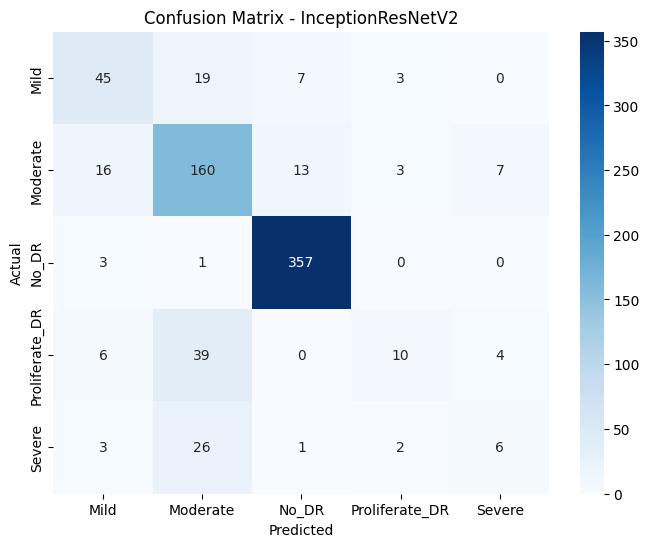

<Figure size 640x480 with 0 Axes>

In [19]:

cm = confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - InceptionResNetV2")

plt.show()

plt.savefig(
    "confusion_matrix_inceptionresnetv2.png"
)

In [20]:
print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
))


                precision    recall  f1-score   support

          Mild       0.62      0.61      0.61        74
      Moderate       0.65      0.80      0.72       199
         No_DR       0.94      0.99      0.97       361
Proliferate_DR       0.56      0.17      0.26        59
        Severe       0.35      0.16      0.22        38

      accuracy                           0.79       731
     macro avg       0.62      0.55      0.56       731
  weighted avg       0.77      0.79      0.77       731



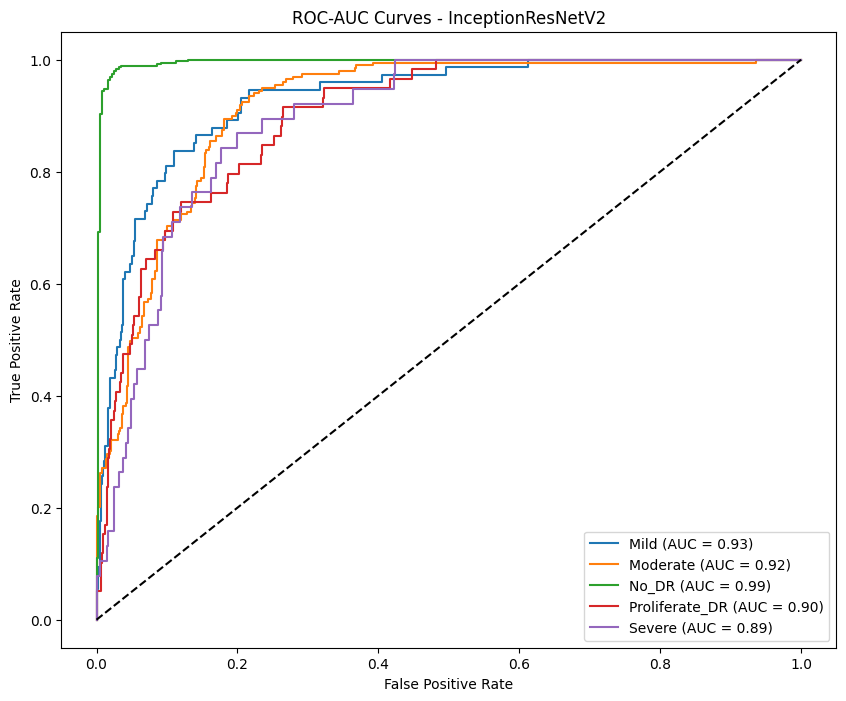

<Figure size 640x480 with 0 Axes>

In [21]:
y_bin = label_binarize(
    true_classes,
    classes=[0,1,2,3,4]
)

plt.figure(figsize=(10,8))

for i in range(5):

    fpr, tpr, _ = roc_curve(
        y_bin[:, i],
        pred_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curves - InceptionResNetV2")

plt.legend()

plt.show()

plt.savefig("roc_auc_inceptionresnetv2.png")


In [22]:
overall_auc = roc_auc_score(
    y_bin,
    pred_probs,
    multi_class='ovr'
)

print("Overall ROC-AUC:", overall_auc)

Overall ROC-AUC: 0.926899335099397


In [23]:
sample_batch = next(val_generator)

sample_images = sample_batch[0]
sample_labels = sample_batch[1]

sample_image = sample_images[0]

sample_input = np.expand_dims(sample_image, axis=0)

prediction = model.predict(sample_input)

predicted_class = np.argmax(prediction)

true_class = np.argmax(sample_labels[0])

print("True:", class_names[true_class])

print("Predicted:", class_names[predicted_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
True: Mild
Predicted: No_DR


In [24]:
for layer in model.layers[-20:]:
    print(layer.name)


batch_normalization_200
activation_200
conv2d_201
batch_normalization_201
activation_201
conv2d_199
conv2d_202
batch_normalization_199
batch_normalization_202
activation_199
activation_202
block8_10_mixed
block8_10_conv
custom_scale_layer_39
conv_7b
conv_7b_bn
conv_7b_ac
global_average_pooling2d
dropout
dense


In [25]:
explainer = GradCAM()

data = ([sample_image], None)

grid = explainer.explain(
    data,
    model,
    class_index=predicted_class,
    layer_name='conv_7b_ac'
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


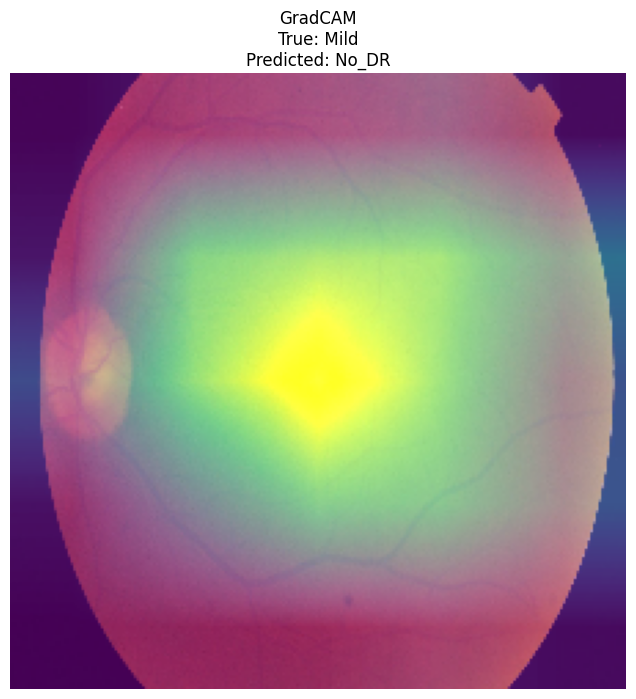

In [33]:
plt.figure(figsize=(8,8))

plt.imshow(grid)

plt.title(
    f"GradCAM\n"
    f"True: {class_names[true_class]}\n"
    f"Predicted: {class_names[predicted_class]}"
)

plt.axis('off')

plt.show()

In [27]:
cv2.imwrite(
    "gradcam_output.png",
    cv2.cvtColor(grid, cv2.COLOR_RGB2BGR)
)

True

In [28]:
if predicted_class == true_class:

    print("✅ Correct Prediction")

else:

    print("❌ Wrong Prediction")


❌ Wrong Prediction


In [29]:
acc = (
    history_stage1.history['accuracy']
    + history_stage2.history['accuracy']
)

val_acc = (
    history_stage1.history['val_accuracy']
    + history_stage2.history['val_accuracy']
)

loss = (
    history_stage1.history['loss']
    + history_stage2.history['loss']
)

val_loss = (
    history_stage1.history['val_loss']
    + history_stage2.history['val_loss']
)

epochs_range = range(len(acc))

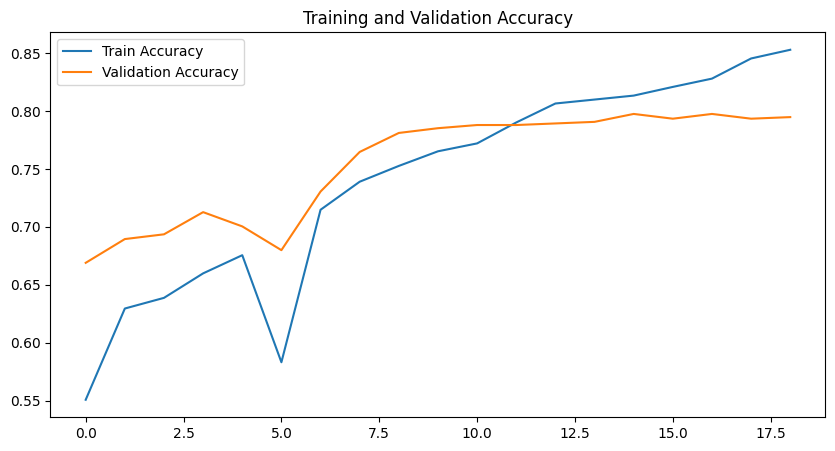

In [30]:
plt.figure(figsize=(10,5))

plt.plot(epochs_range, acc, label='Train Accuracy')

plt.plot(epochs_range, val_acc, label='Validation Accuracy')

plt.legend()

plt.title("Training and Validation Accuracy")

plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

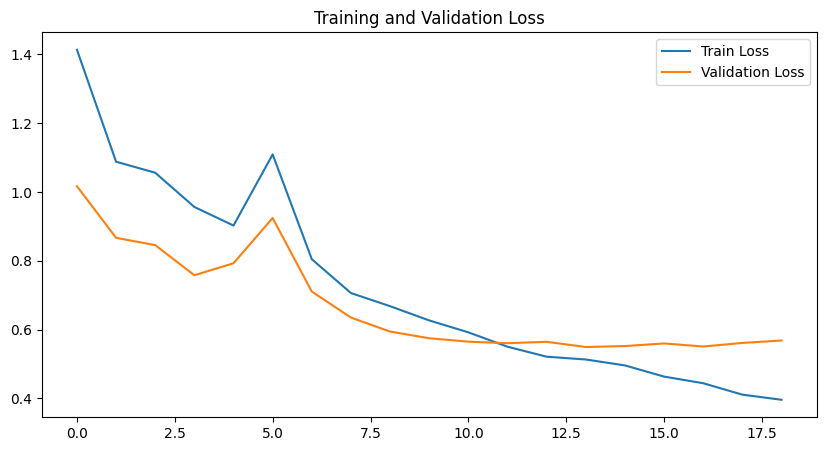

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(epochs_range, loss, label='Train Loss')

plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.legend()

plt.title("Training and Validation Loss")

plt.show

In [ ]:
checkpoint_data = {
    "class_names": class_names,
    "model_name": "InceptionResNetV2",
    "input_size": 224
}

print("Checkpoint metadata:", checkpoint_data)
